## 📖 About the Dataset

The **World Happiness Report** is an annual publication by the United Nations Sustainable Development Solutions Network. It ranks countries based on how happy their citizens perceive themselves to be, using survey data and several key indicators.

The happiness score is based on a combination of:
- Economic performance (GDP)
- Social factors (freedom, support, trust)
- Health (life expectancy)
- Others

Each country is scored on a scale from 0 to 10.

The dataset contains the following main columns:
| Column Name                       | Description                                          |
| --------------------------------- | ---------------------------------------------------- |
| `Country`                         | Name of the country                                  |
| `Happiness Score`                 | Overall happiness score (0 to 10)                    |
| `Lower/Upper Confidence Interval` | Statistical range of the happiness score             |
| `GDP per Capita`                  | Economic output per person (logged)                  |
| `Social Support`                  | Perceived availability of social support             |
| `Healthy Life Expectancy`         | Expected years of healthy living                     |
| `Freedom to Make Life Choices`    | Perception of freedom in life decisions              |
| `Perceptions of Corruption`       | Perceived level of corruption in government/business |
| `Generosity`                      | Donations and altruistic behavior                    |
| `Dystopia Residual`               | capturing other unmeasured factors that make people happy (e.g., culture, resilience, public services, etc.). It may differ for each country so we will not to analyze it|


In [156]:
import pandas as pd

data = pd.read_csv("/home/noveliopi/eda-world-happiness/data/World Happiness 2024.csv", sep=";")
data.head()

,Country,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom to Make Life Choice,Perception of Corruption,Generosity,Dystopia Residual
0,Finland,7.741,7.667,7.815,1.844,1.572,0.695,0.859,0.546,0.142,2.082
1,Denmark,7.583,7.500,7.665,1.908,1.520,0.699,0.823,0.548,0.204,1.881
2,Iceland,7.525,7.433,7.618,1.881,1.617,0.718,0.819,0.182,0.258,2.050
3,Sweden,7.344,7.267,7.422,1.878,1.501,0.724,0.838,0.524,0.221,1.658
4,Israel,7.341,7.277,7.405,1.803,1.513,0.740,0.641,0.193,0.153,2.298


## 📊 Analysis

In [157]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      143 non-null    object 
 1   Happiness Score              143 non-null    float64
 2   Lower Confidence Interval    143 non-null    float64
 3   Upper Confidence Interval    143 non-null    float64
 4   GDP per Capita               140 non-null    float64
 5   Social Support               140 non-null    float64
 6   Healthy Life Expectancy      140 non-null    float64
 7   Freedom to Make Life Choice  140 non-null    float64
 8   Perception of Corruption     140 non-null    float64
 9   Generosity                   140 non-null    float64
 10  Dystopia Residual            140 non-null    float64
dtypes: float64(10), object(1)
memory usage: 12.4+ KB


There are several null data points, we should check them first to decide whether they need to be dropped or not.

In [158]:
nan_data = data[data.isna().any(axis=1)]
nan_data

,Country,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom to Make Life Choice,Perception of Corruption,Generosity,Dystopia Residual
61,Bahrain,5.959,5.766,6.153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87,Tajikistan,5.281,5.201,5.361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102,State of Palestine,4.879,4.753,5.006,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We can see that all of the parameters in these three countries are null/NaN, so it's better to drop them.

In [159]:
data = data.dropna()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      140 non-null    object 
 1   Happiness Score              140 non-null    float64
 2   Lower Confidence Interval    140 non-null    float64
 3   Upper Confidence Interval    140 non-null    float64
 4   GDP per Capita               140 non-null    float64
 5   Social Support               140 non-null    float64
 6   Healthy Life Expectancy      140 non-null    float64
 7   Freedom to Make Life Choice  140 non-null    float64
 8   Perception of Corruption     140 non-null    float64
 9   Generosity                   140 non-null    float64
 10  Dystopia Residual            140 non-null    float64
dtypes: float64(10), object(1)
memory usage: 13.1+ KB


,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom to Make Life Choice,Perception of Corruption,Generosity,Dystopia Residual
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,5.530893,5.417700,5.644057,1.378807,1.134329,0.520886,0.620621,0.154121,0.146271,1.575914
std,1.181247,1.198051,1.165108,0.425098,0.333317,0.164923,0.162492,0.126238,0.073441,0.537459
min,1.721000,1.667000,1.775000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.073000
25%,4.631750,4.503750,4.762250,1.077750,0.921750,0.398000,0.527500,0.068750,0.091000,1.308250
50%,5.800500,5.676500,5.911000,1.431500,1.237500,0.549500,0.641000,0.120500,0.136500,1.644500
75%,6.426250,6.338250,6.515250,1.741500,1.383250,0.648500,0.736000,0.193750,0.192500,1.881750
max,7.741000,7.667000,7.815000,2.141000,1.617000,0.857000,0.863000,0.575000,0.401000,2.998000


In [160]:
data[data["Happiness Score"] > data["Happiness Score"].mean()]

,Country,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom to Make Life Choice,Perception of Corruption,Generosity,Dystopia Residual
0,Finland,7.741,7.667,7.815,1.844,1.572,0.695,0.859,0.546,0.142,2.082
1,Denmark,7.583,7.500,7.665,1.908,1.520,0.699,0.823,0.548,0.204,1.881
2,Iceland,7.525,7.433,7.618,1.881,1.617,0.718,0.819,0.182,0.258,2.050
3,Sweden,7.344,7.267,7.422,1.878,1.501,0.724,0.838,0.524,0.221,1.658
4,Israel,7.341,7.277,7.405,1.803,1.513,0.740,0.641,0.193,0.153,2.298
...,...,...,...,...,...,...,...,...,...,...,...
75,Montenegro,5.707,5.599,5.815,1.571,1.318,0.587,0.632,0.132,0.110,1.357
76,Mongolia,5.696,5.610,5.783,1.353,1.511,0.400,0.501,0.055,0.237,1.640
77,Colombia,5.695,5.584,5.806,1.437,1.241,0.648,0.644,0.059,0.072,1.596
78,Venezuela,5.607,5.489,5.725,0.000,1.321,0.491,0.518,0.086,0.192,2.998


the total of the countries that have happiness score above avarage is more than a half, so we can gratefull for it.

Indonesia tend to be the last country in the rank for happiest country above the average.

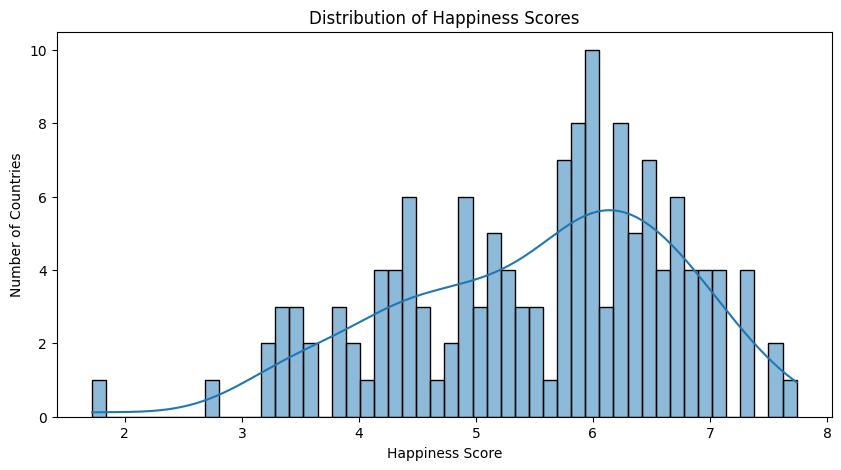

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data['Happiness Score'], bins=50, kde=True)
plt.title("Distribution of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Number of Countries")
plt.show()

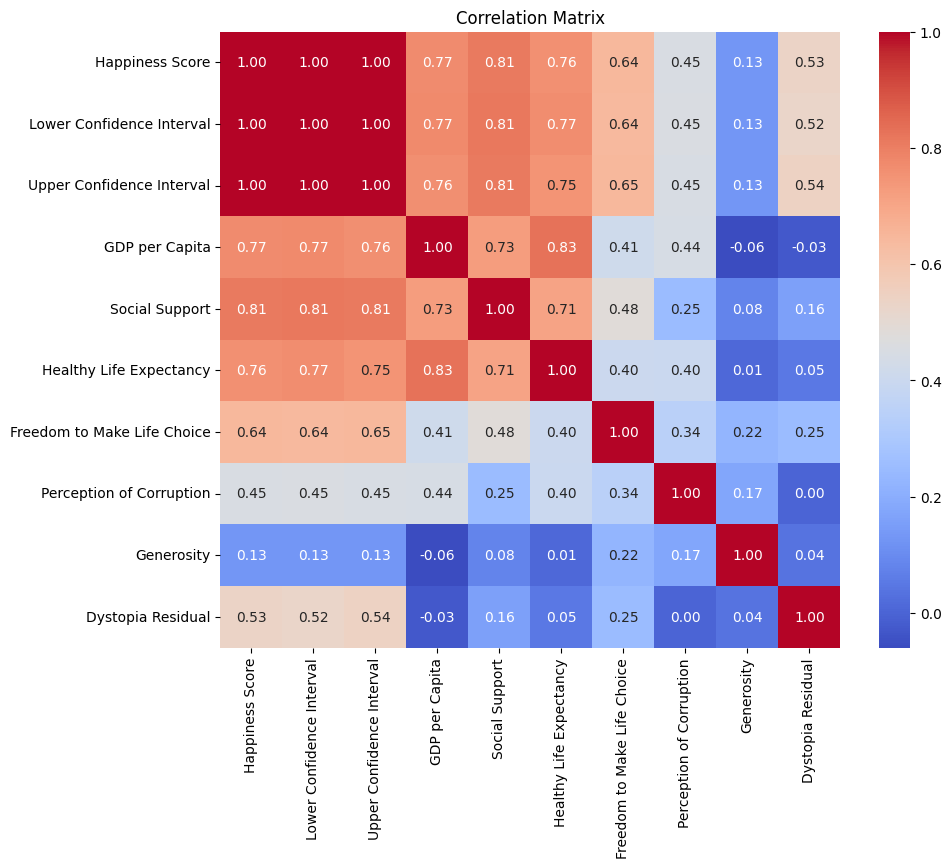

In [162]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.drop("Country", axis=1).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

- `Social support` is the most strongly correlated feature with the Happiness Score, suggesting that people who feel supported by family, friends, or social systems tend to report higher happiness.

- Higher economic output per person tends to correlate well with happiness. Better health and longevity are also closely tied to happiness. This implies that money and healthiness contributes to happiness, but not as strongly as social bonds.

- The correlation between `GDP per Capita` and `Healthy Life Expectancy` shows that wealthier nations tend to have better healthcare systems and longer life expectancy.

- Countries with less perceived corruption tend to have happier populations.

- `Generosity` has near-zero or even slightly negative correlations with `GDP per Capita` and `Healthy Life Expectancy`. This might imply that wealthier countries are not necessarily more generous at a societal level, or the measurement method for generosity varies culturally.



In [163]:
def visualize_and_detect_outlier(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]

    print(f"\nOutliers in {column}:")
    print(outliers[['Country', column]])

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=data, x=column)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Outliers in GDP per Capita:
      Country  GDP per Capita
78  Venezuela             0.0


/tmp/ipykernel_19986/1544693741.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


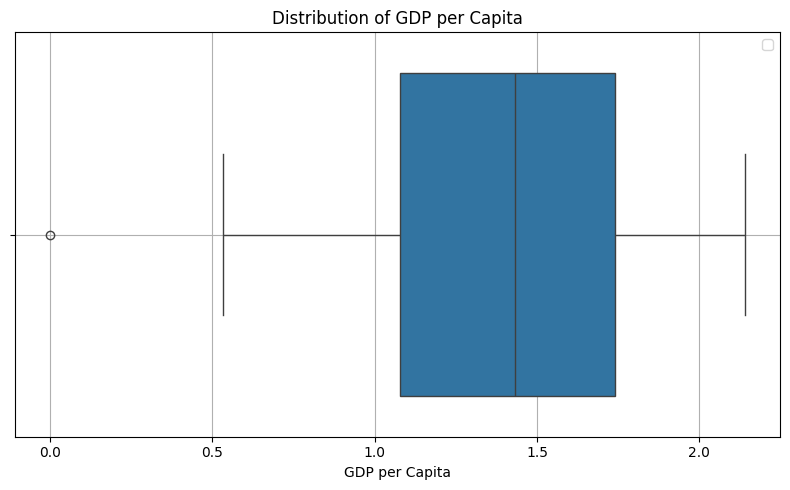

In [164]:
visualize_and_detect_outlier(data, "GDP per Capita")

Despite having the lowest possible GDP per Capita value (0.0), Venezuela reports a moderate happiness score, which defies the overall trend. This likely influenced by data anomalies, reporting differences, or socio-cultural factors that aren't captured by GDP alone.

/tmp/ipykernel_19986/1544693741.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()



Outliers in Social Support:
         Country  Social Support
115        Benin           0.128
142  Afghanistan           0.000


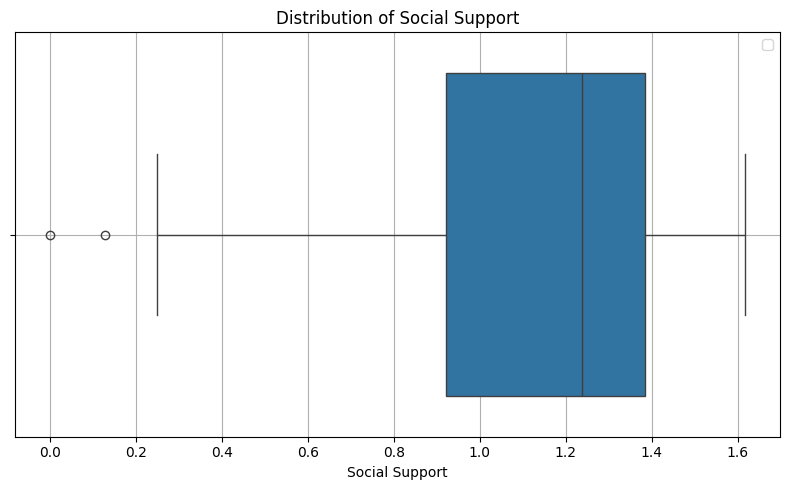

In [165]:
visualize_and_detect_outlier(data, "Social Support")

It shows that social support highly affect the happiness of the country


Outliers in Healthy Life Expectancy:
     Country  Healthy Life Expectancy
140  Lesotho                      0.0


/tmp/ipykernel_19986/1544693741.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


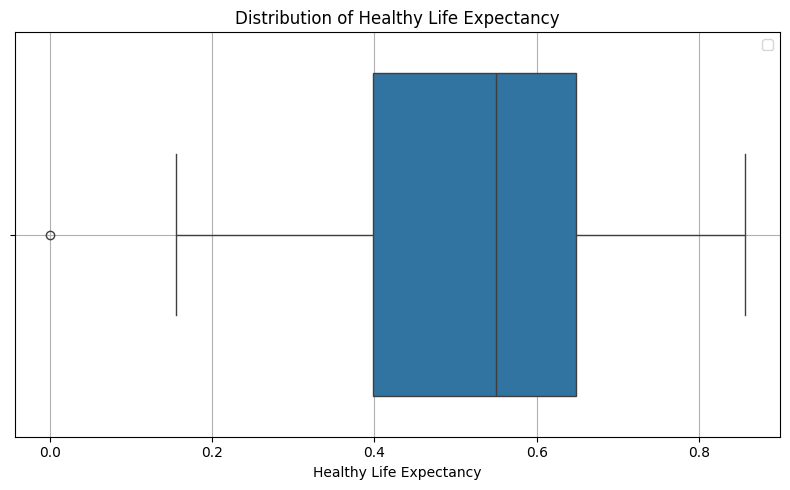

In [166]:
visualize_and_detect_outlier(data, "Healthy Life Expectancy")


Outliers in Freedom to Make Life Choice:
         Country  Freedom to Make Life Choice
97       Turkiye                        0.202
131      Comoros                        0.172
141      Lebanon                        0.173
142  Afghanistan                        0.000


/tmp/ipykernel_19986/1544693741.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


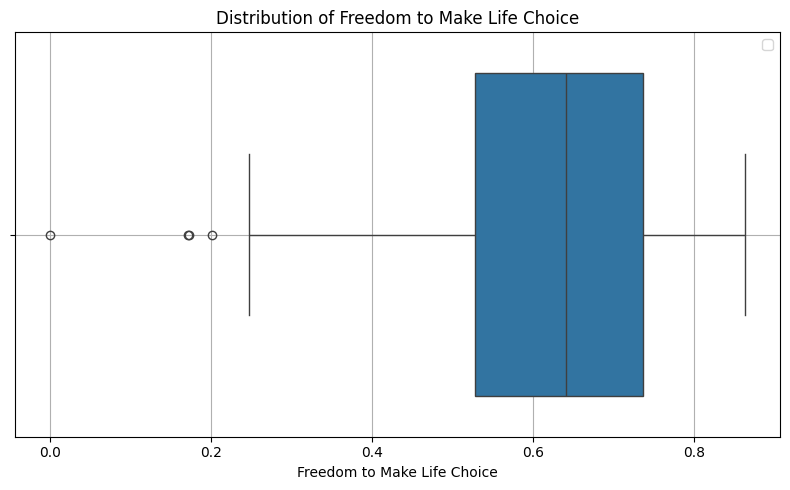

In [167]:
visualize_and_detect_outlier(data, "Freedom to Make Life Choice")

All outliers with low values for freedom to make life choices originate from Muslim-majority countries. This pattern may suggest that in some places, certain ways of interpreting Islam are linked to stricter social rules. however, further analysis across a broader set of Muslim-majority countries is necessary to confirms this hypothesis.

/tmp/ipykernel_19986/1544693741.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()



Outliers in Perception of Corruption:
                      Country  Perception of Corruption
0                     Finland                     0.546
1                     Denmark                     0.548
3                      Sweden                     0.524
6                      Norway                     0.484
7                  Luxembourg                     0.432
8                 Switzerland                     0.498
10                New Zealand                     0.480
16                    Ireland                     0.418
29                  Singapore                     0.575
33                    Estonia                     0.401
85  Hong Kong S.A.R. of China                     0.402


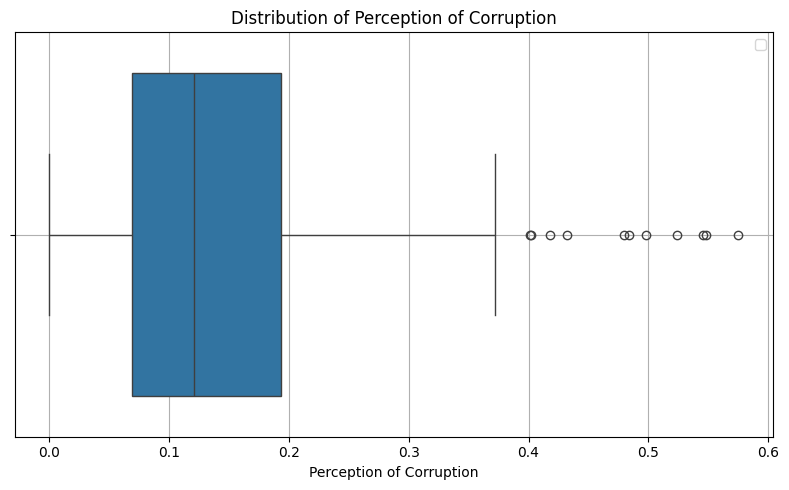

In [168]:
visualize_and_detect_outlier(data, "Perception of Corruption")

This suggests that reducing corruption may lead to increased national happiness, potentially through improved public services, greater trust in institutions, and enhanced economic prosperity. However, the presence of high-value outliers indicates that many countries still experience significant levels of corruption.


Outliers in Generosity:
       Country  Generosity
79   Indonesia       0.399
117    Myanmar       0.401


/tmp/ipykernel_19986/1544693741.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


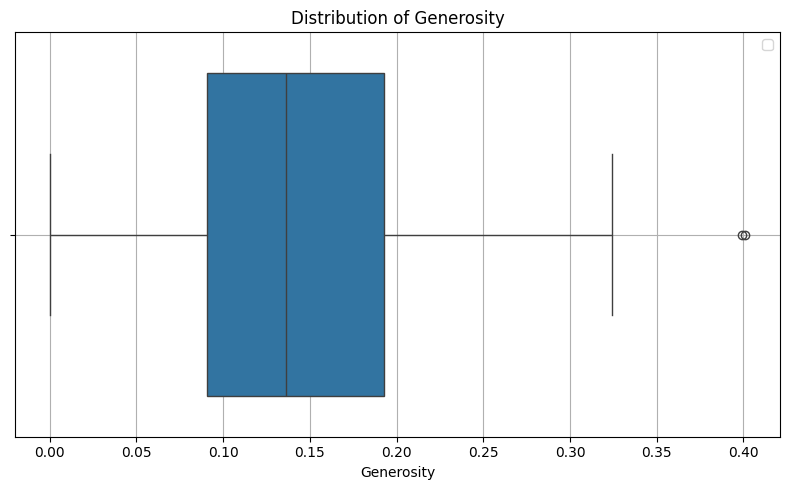

In [169]:
visualize_and_detect_outlier(data, "Generosity")

Since people in Indonesia and Myanmar seem to be very generous, charities and community projects could do well by working more in these countries. Local people may be more willing to help, give, or volunteer, which could make these programs more successful.

## 🌍 10 Most ... Countries

In [170]:
def most_n_countries(data, n, column):
    top10 = data.nlargest(n, column)
    bottom10 = data.nsmallest(n, column)[::-1]  # reverse for visual order

    # Create a blank row for spacing
    blank_row = pd.DataFrame({col: [None] for col in data.columns})
    blank_row['Country'] = '. . .'

    # Concatenate with spacing
    combined = pd.concat([top10, blank_row, bottom10], ignore_index=True)

    # Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x=column, y='Country', data=combined, hue='Country', palette='coolwarm')
    plt.title(f'Top {n} and Bottom {n} Countries by {column}')
    plt.xlabel(column)
    plt.ylabel('Country')
    plt.grid(True)
    plt.show()

### 10 Most happy countries

/tmp/ipykernel_19986/4194205920.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([top10, blank_row, bottom10], ignore_index=True)


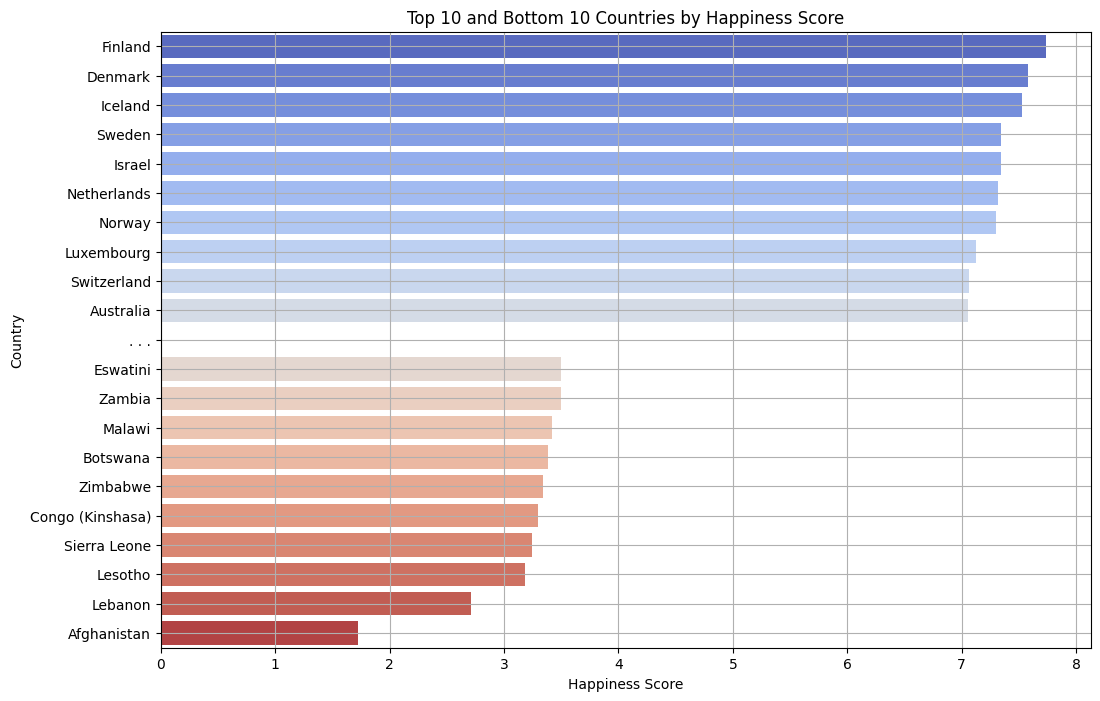

In [171]:
most_n_countries(data, 10, "Happiness Score")

### 10 Highest GDP per Capita Country

/tmp/ipykernel_19986/4194205920.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([top10, blank_row, bottom10], ignore_index=True)


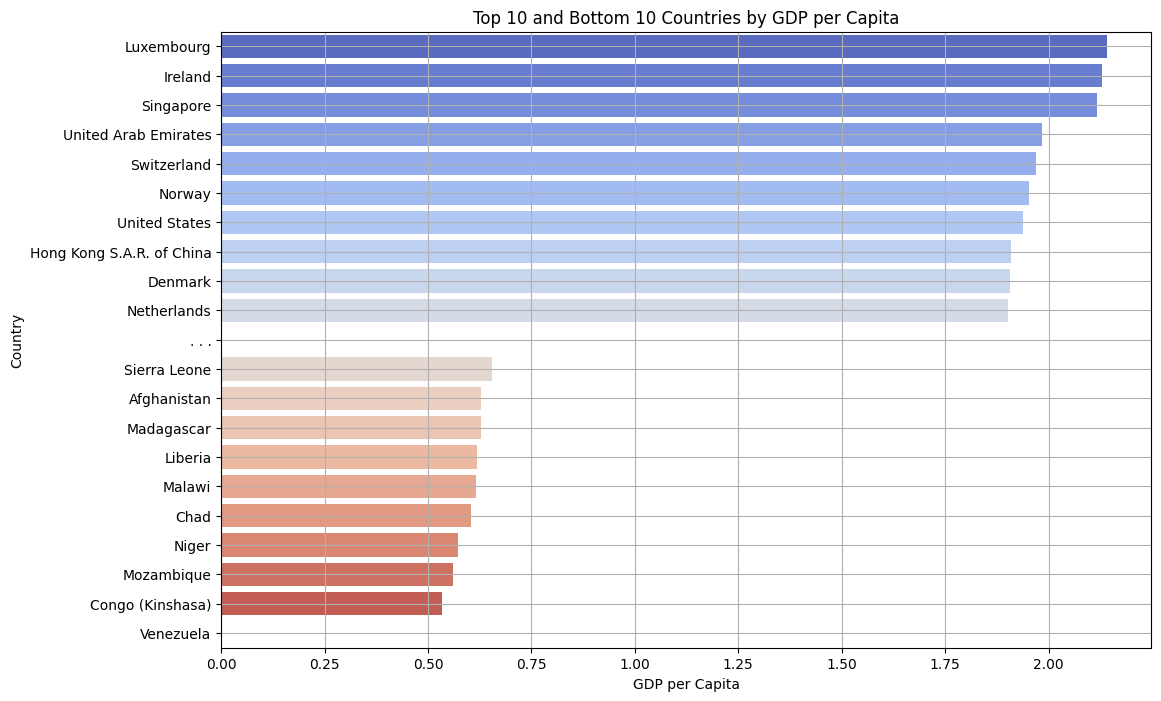

In [172]:
most_n_countries(data, 10, "GDP per Capita")

The highest GDP per capita is observed in Luxembourg, followed closely by Ireland and Singapore. These countries are generally small, well-developed, and have strong service sectors (especially finance and tech). Their wealth per person is very high due to thriving industries like banking (Luxembourg, Switzerland), tech and pharma (Ireland), and logistics and finance (Singapore).

Most of the lowest-ranking countries are in sub-Saharan Africa. These countries often face challenges such as political instability, conflict, poor infrastructure, and reliance on primary industries.

/tmp/ipykernel_19986/4194205920.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([top10, blank_row, bottom10], ignore_index=True)


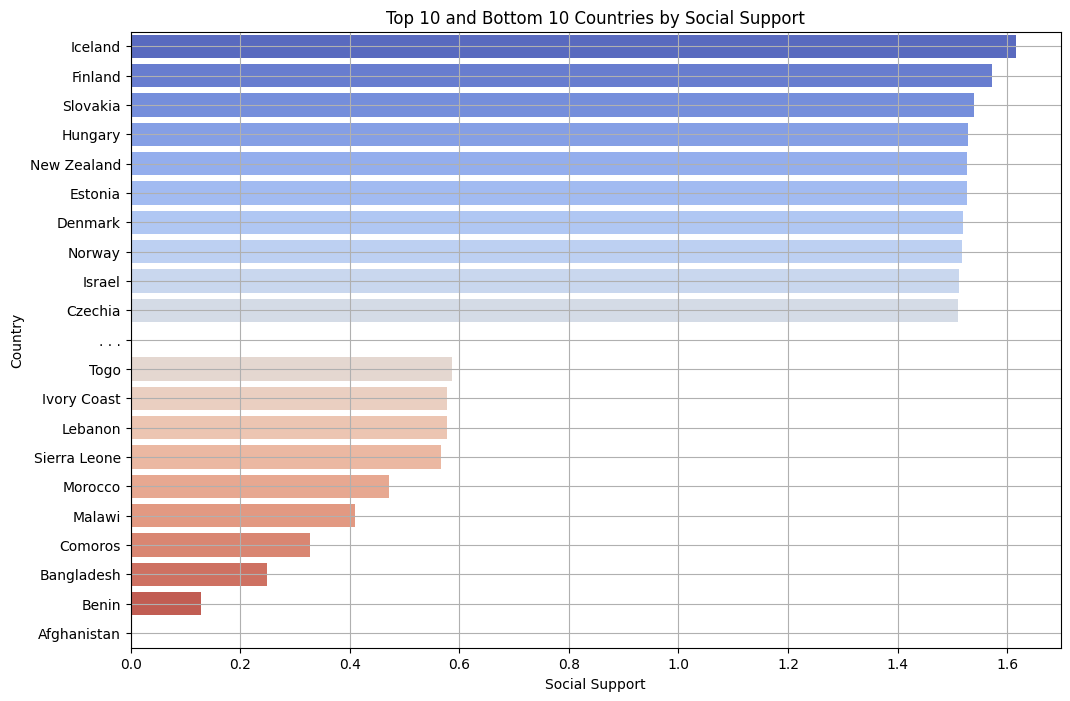

In [173]:
most_n_countries(data, 10, "Social Support")

Many of top listed are Nordic or European countries where people may tend to feel supported not just by family, but also by the government and wider community.

/tmp/ipykernel_19986/4194205920.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([top10, blank_row, bottom10], ignore_index=True)


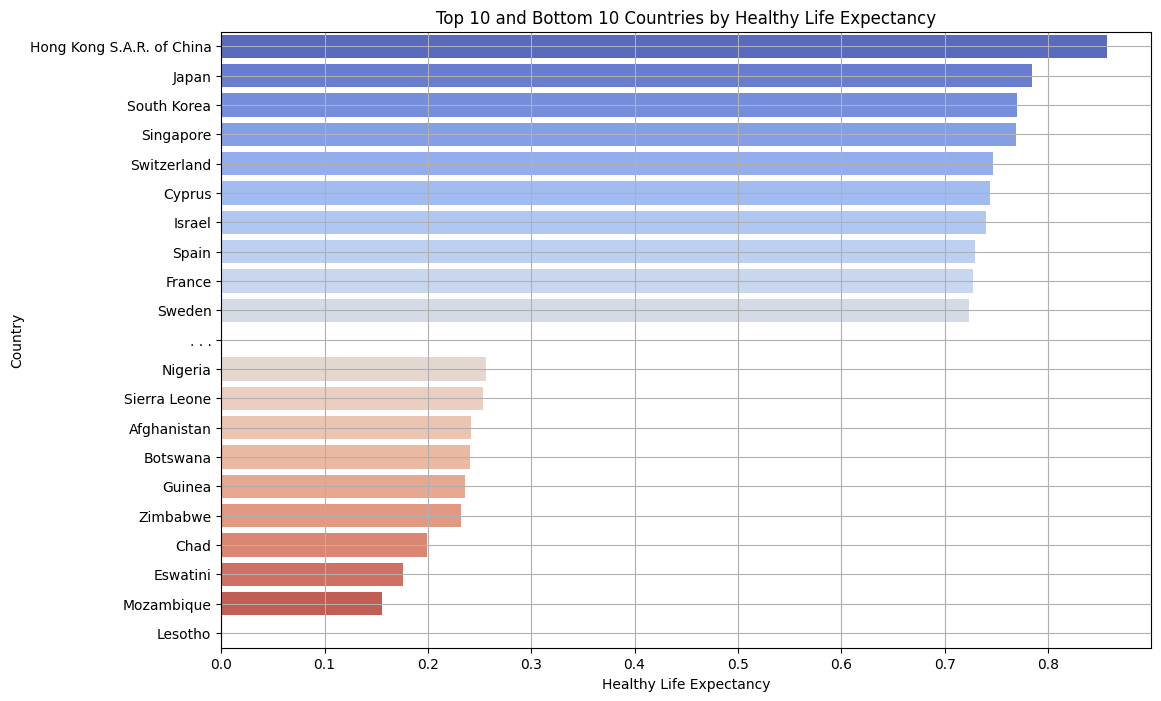

In [174]:
most_n_countries(data, 10, "Healthy Life Expectancy")

 the lowest-ranking countries, mostly in sub-Saharan Africa. These countries often face limited access to quality healthcare, high rates of infectious diseases (like HIV/AIDS, malaria, and TB), poor nutrition and sanitation, and political and economic instability.

/tmp/ipykernel_19986/4194205920.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([top10, blank_row, bottom10], ignore_index=True)


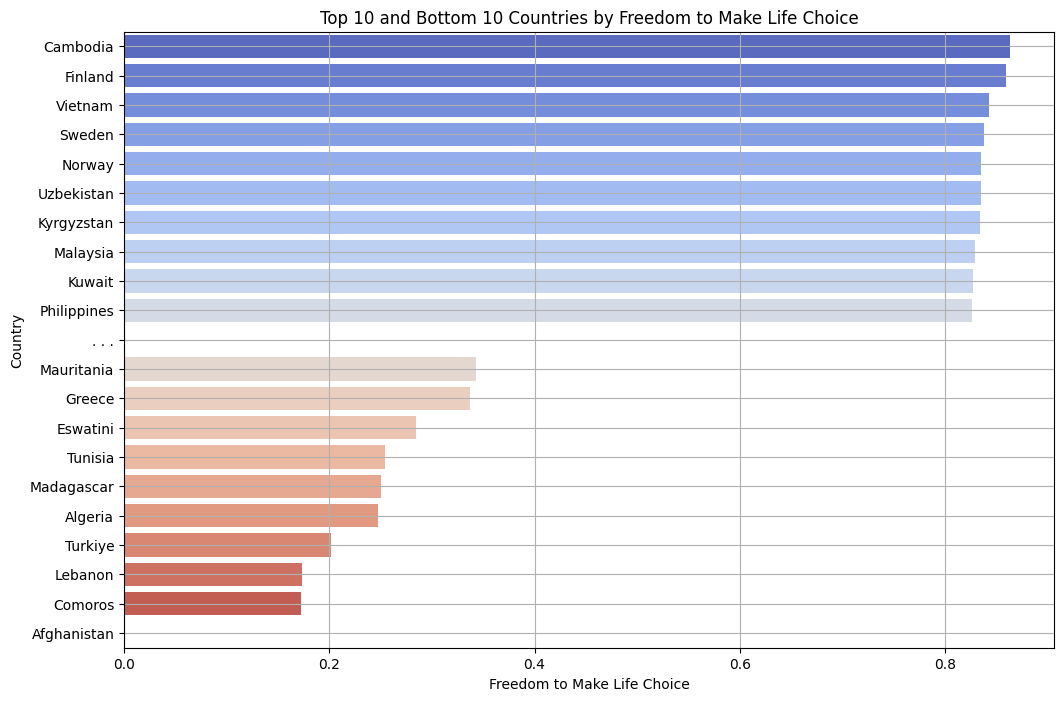

In [175]:
most_n_countries(data, 10, "Freedom to Make Life Choice")

While some of the top-ranking countries are known for their secular governance and strong civil liberties (e.g., Finland, Sweden, Norway), others (e.g., Vietnam, Cambodia) have more centralized or authoritarian systems, suggesting that high freedom in life choice does not strictly correlate with democratic governance or secularism alone.

Conversely, the lowest-ranking countries often experience political instability, strong religious or cultural constraints, or weaker institutional protections for individual rights.

Overall, the data suggests that freedom to make life choices is influenced by a complex combination of social, political, and cultural factors, and cannot be attributed to a single variable like religious affiliation or governance style alone. So, it may give us an answer for our hypothesis before about Muslim-majority countries.

/tmp/ipykernel_19986/4194205920.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([top10, blank_row, bottom10], ignore_index=True)


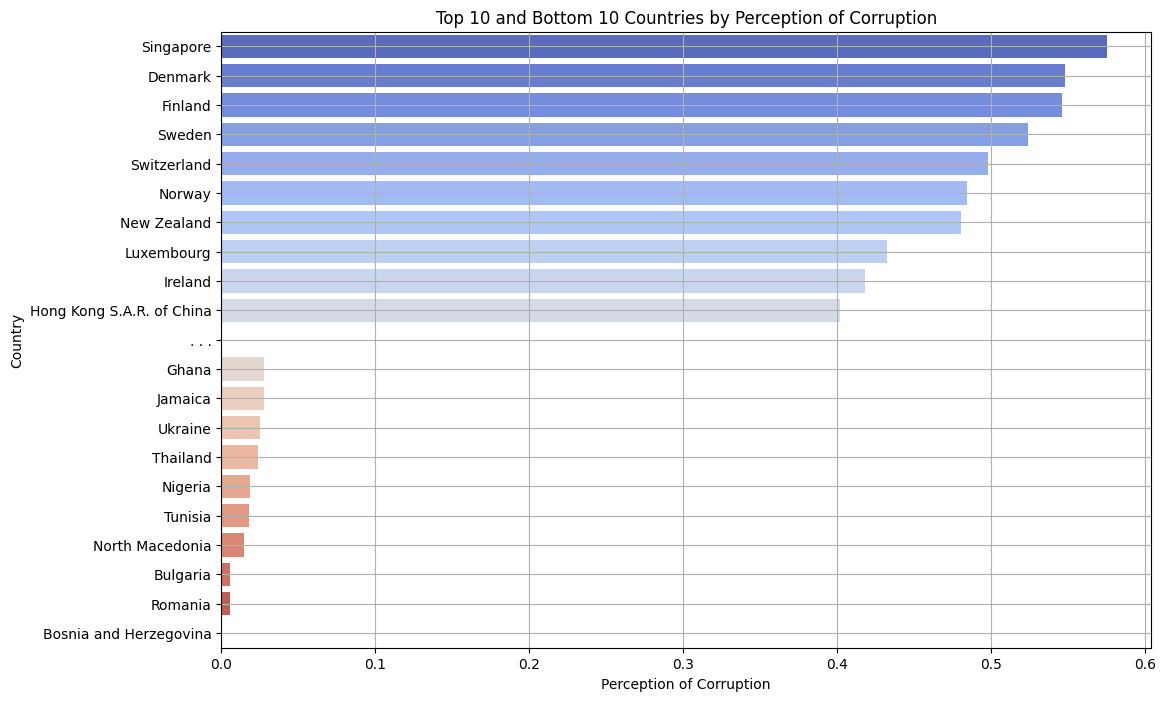

In [176]:
most_n_countries(data, 10, "Perception of Corruption")

At the bottom, we see countries where corruption is seen as a bigger problem. These nations often deal with weak institutions, political instability, and less public trust in the system. Many of them are still developing or recovering from past conflict or political issues.

## 🎯 Conclusion

- Social support, GDP, and Healthy have strong positive correlations with happiness.
- 